# **Advertisement Budget Project**
# ====================================

In [12]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Statistical modelling
import statsmodels.api as sm

# Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Display settings
pd.set_option("display.precision", 3)

# Reproducibility
RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


In [56]:
import pandas as pd

advertising = pd.read_csv("Advertising.csv")

advertising.head()


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [58]:
df = pd.read_csv("Advertising.csv")

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 200
Columns: 5


##  Data Quality 
### We get the dimension of the dataset. The dataset has 200 rows and 4 columns.

In [15]:
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB

Missing values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

Duplicate rows:
0


In [16]:
#Check Zero Values 

zero_counts = (df == 0).sum()

print(zero_counts)

Unnamed: 0    0
TV            0
Radio         1
Newspaper     0
Sales         0
dtype: int64


In [60]:
#Exploratory Data Analysis
pd.set_option('display.precision',2)#new feature is display.precision
advertising.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.00,200.00,200.00,200.00,200.00
mean,100.50,147.04,23.26,30.55,14.02
std,57.88,85.85,14.85,21.78,5.22
min,1.00,0.70,0.00,0.30,1.60
25%,50.75,74.38,9.97,12.75,10.38
50%,100.50,149.75,22.90,25.75,12.90
75%,150.25,218.82,36.52,45.10,17.40
max,200.00,296.40,49.60,114.00,27.00


### Analysis of Zero Values in Predictors

In [62]:
(advertising == 0).sum(axis=0)


Unnamed: 0    0
TV            0
Radio         1
Newspaper     0
Sales         0
dtype: int64

In [64]:
#Response Variable Analysis
advertising.Sales.value_counts()

Sales
9.7     5
11.7    4
12.9    4
15.9    4
20.7    3
       ..
17.0    1
18.3    1
22.3    1
14.0    1
25.5    1
Name: count, Length: 121, dtype: int64

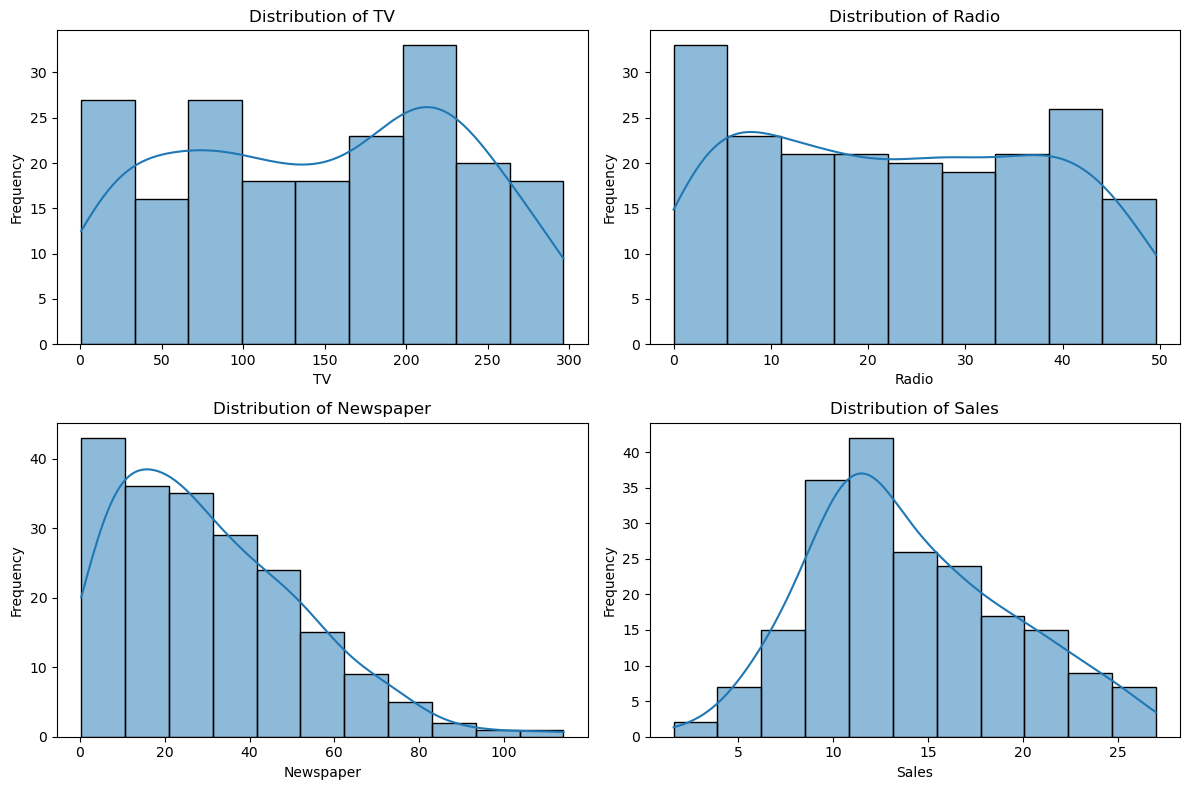

In [66]:
#EDA(Explorartory Data Analysis)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

columns = ["TV", "Radio", "Newspaper", "Sales"]

for ax, col in zip(axes.flat, columns):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Advertising vs Sales

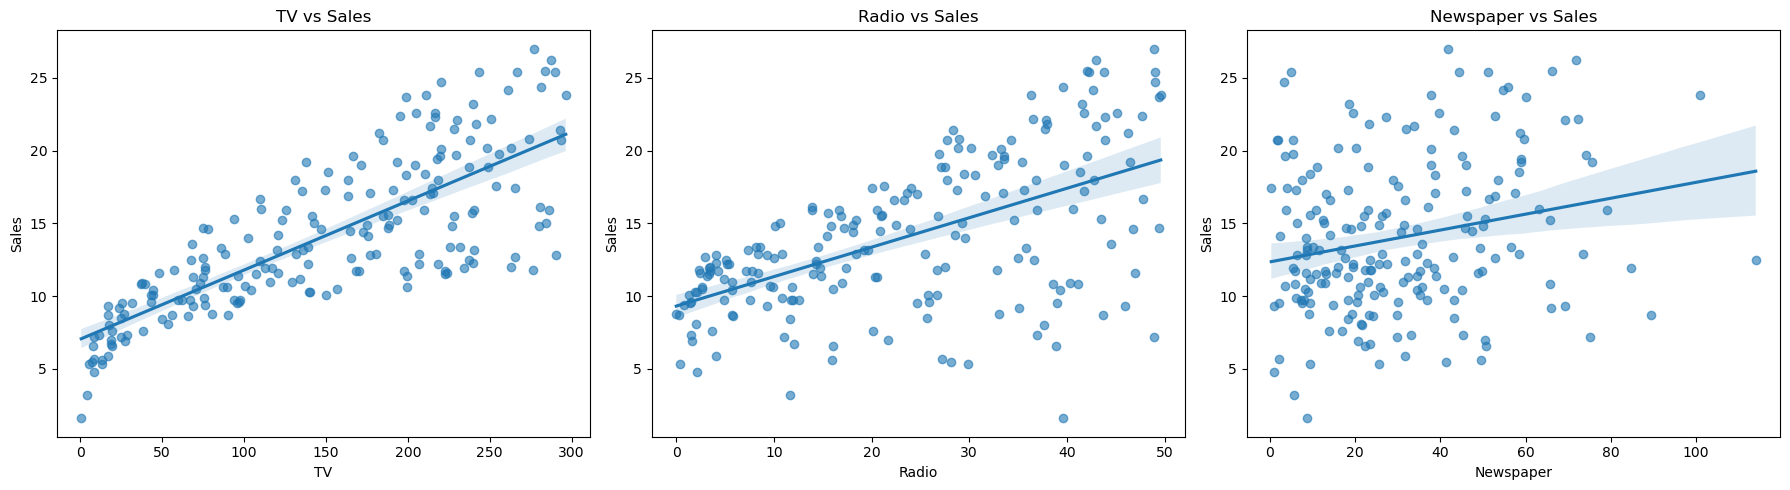

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ["TV", "Radio", "Newspaper"]

for ax, feature in zip(axes, features):
    sns.regplot(
        data=df,
        x=feature,
        y="Sales",
        ax=ax,
        scatter_kws={"alpha": 0.6}
    )
    ax.set_title(f"{feature} vs Sales")

plt.tight_layout()
plt.show() 

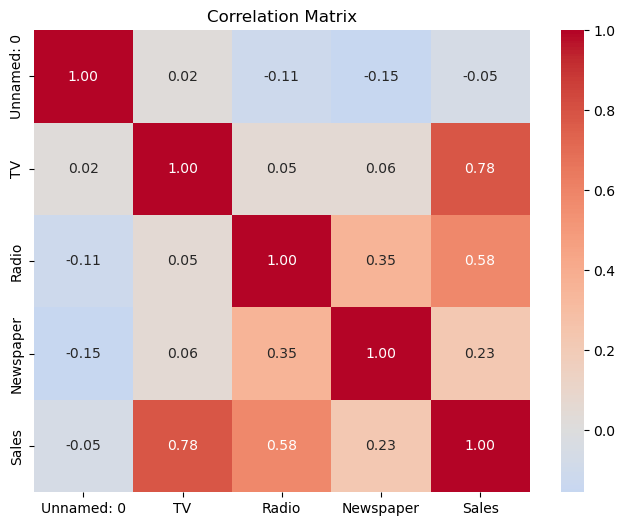

In [70]:
# Correalation Matrix 
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.show()

In [72]:
#Separate Features and Target 
X = df[["TV", "Radio", "Newspaper"]]

y = df["Sales"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['TV', 'Radio', 'Newspaper']

Target:
Sales


In [74]:
#Train - test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


In [76]:
#Build a Machine Learning Pipeline 
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

### Train Model 

In [78]:
linear_pipeline.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


### Make Predictions 

In [80]:
y_pred = linear_pipeline.predict(X_test)

results = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": y_pred
})

results.head(10)

,Actual Sales,Predicted Sales
0,16.9,16.41
1,22.4,20.89
2,21.4,21.55
3,7.3,10.61
4,24.7,22.11
5,12.6,13.11
6,22.3,21.06
7,8.4,7.46
8,11.5,13.61
9,14.9,15.16


### Model Evaluation 

In [82]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

MAE  : 1.461
MSE  : 3.174
RMSE : 1.782
R²   : 0.899


### Cross Validation

In [84]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "R2": "r2",
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error"
}

cv_results = cross_validate(
    linear_pipeline,
    X,
    y,
    cv=cv,
    scoring=scoring
)

print("Cross-validation results:")

print(
    "Mean R²:",
    cv_results["test_R2"].mean()
)

print(
    "Mean MAE:",
    -cv_results["test_MAE"].mean()
)

print(
    "Mean RMSE:",
    -cv_results["test_RMSE"].mean()
)

Cross-validation results:
Mean R²: 0.882730398516032
Mean MAE: 1.287265345593072
Mean RMSE: 1.705731505144976


#### Compare Actual vs Predicted

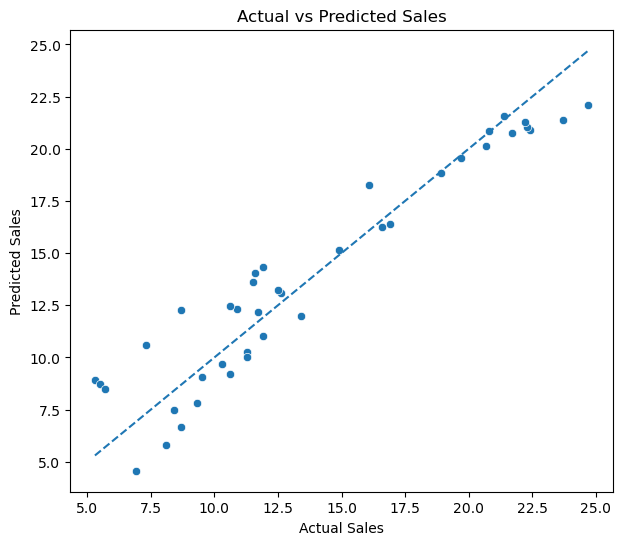

In [86]:
plt.figure(figsize=(7, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

### Residual Analysis

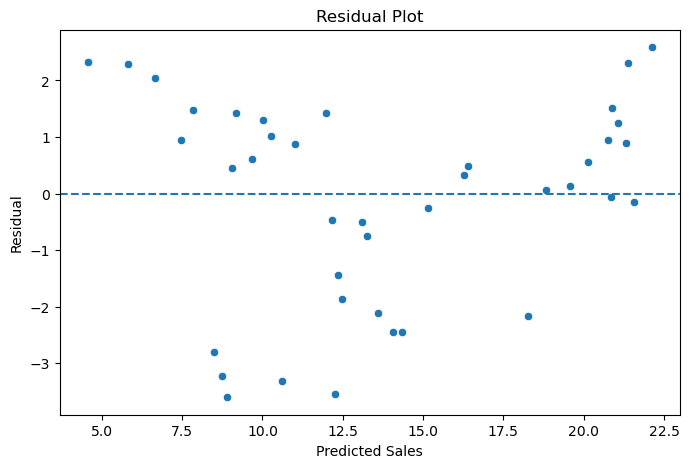

In [88]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

#### Residual Distribution

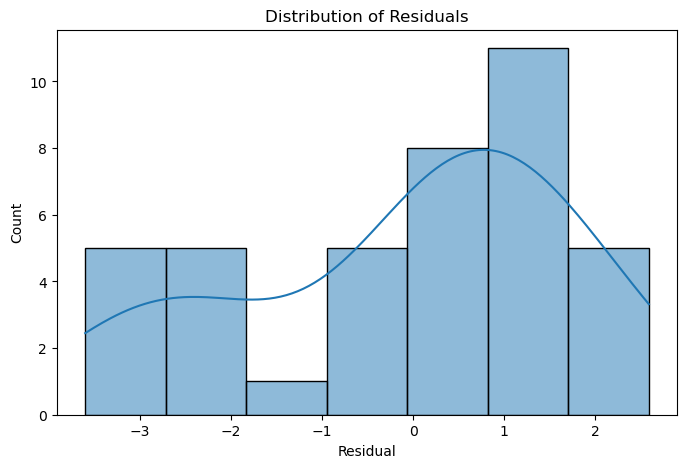

In [90]:
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.xlabel("Residual")
plt.title("Distribution of Residuals")

plt.show()

### Check Multicollinearity

In [92]:
X_vif = sm.add_constant(X)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif

,Feature,VIF
0,const,6.85
1,TV,1.00
2,Radio,1.14
3,Newspaper,1.15


#### Statistical OLS Model

In [94]:
X_ols = sm.add_constant(X)

ols_model = sm.OLS(y, X_ols).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.58e-96
Time:                        21:12:02   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

#### Statistical OLS Model

In [96]:
X_ols = sm.add_constant(X)

ols_model = sm.OLS(y, X_ols).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Thu, 10 Sep 2026   Prob (F-statistic):           1.58e-96
Time:                        21:12:04   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

### Extract Coefficients

In [98]:
coefficients = pd.DataFrame({
    "Feature": ols_model.params.index,
    "Coefficient": ols_model.params.values,
    "P-value": ols_model.pvalues.values
})

coefficients

,Feature,Coefficient,P-value
0,const,2.94e+00,1.27e-17
1,TV,4.58e-02,1.51e-81
2,Radio,1.89e-01,1.51e-54
3,Newspaper,-1.04e-03,8.60e-01


#### Feature Importance

In [100]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

standardized_model = LinearRegression()

standardized_model.fit(X_scaled, y)

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Standardized Coefficient": standardized_model.coef_
})

feature_importance = feature_importance.sort_values(
    "Standardized Coefficient",
    key=abs,
    ascending=False
)

feature_importance

,Feature,Standardized Coefficient
0,TV,3.92
1,Radio,2.79
2,Newspaper,-0.02


### Compare Models

In [102]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Ridge Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "Lasso Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.1))
    ])
}

### Evaluate All Models

In [104]:
model_results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)
    
    predictions = model.predict(X_test)
    
    model_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(
            mean_squared_error(y_test, predictions)
        ),
        "R2": r2_score(y_test, predictions)
    })

comparison = pd.DataFrame(model_results)

comparison.sort_values(
    "RMSE"
)

,Model,MAE,RMSE,R2
0,Linear Regression,1.46,1.78,0.9
1,Ridge Regression,1.46,1.79,0.9
2,Lasso Regression,1.46,1.79,0.9


### Final Model

In [106]:
final_model = linear_pipeline

### Make a New Business Predictiions 

In [108]:
new_campaign = pd.DataFrame({
    "TV": [200],
    "Radio": [30],
    "Newspaper": [20]
})

predicted_sales = final_model.predict(new_campaign)

print(
    f"Predicted Sales: {predicted_sales[0]:.2f}"
)


Predicted Sales: 17.66


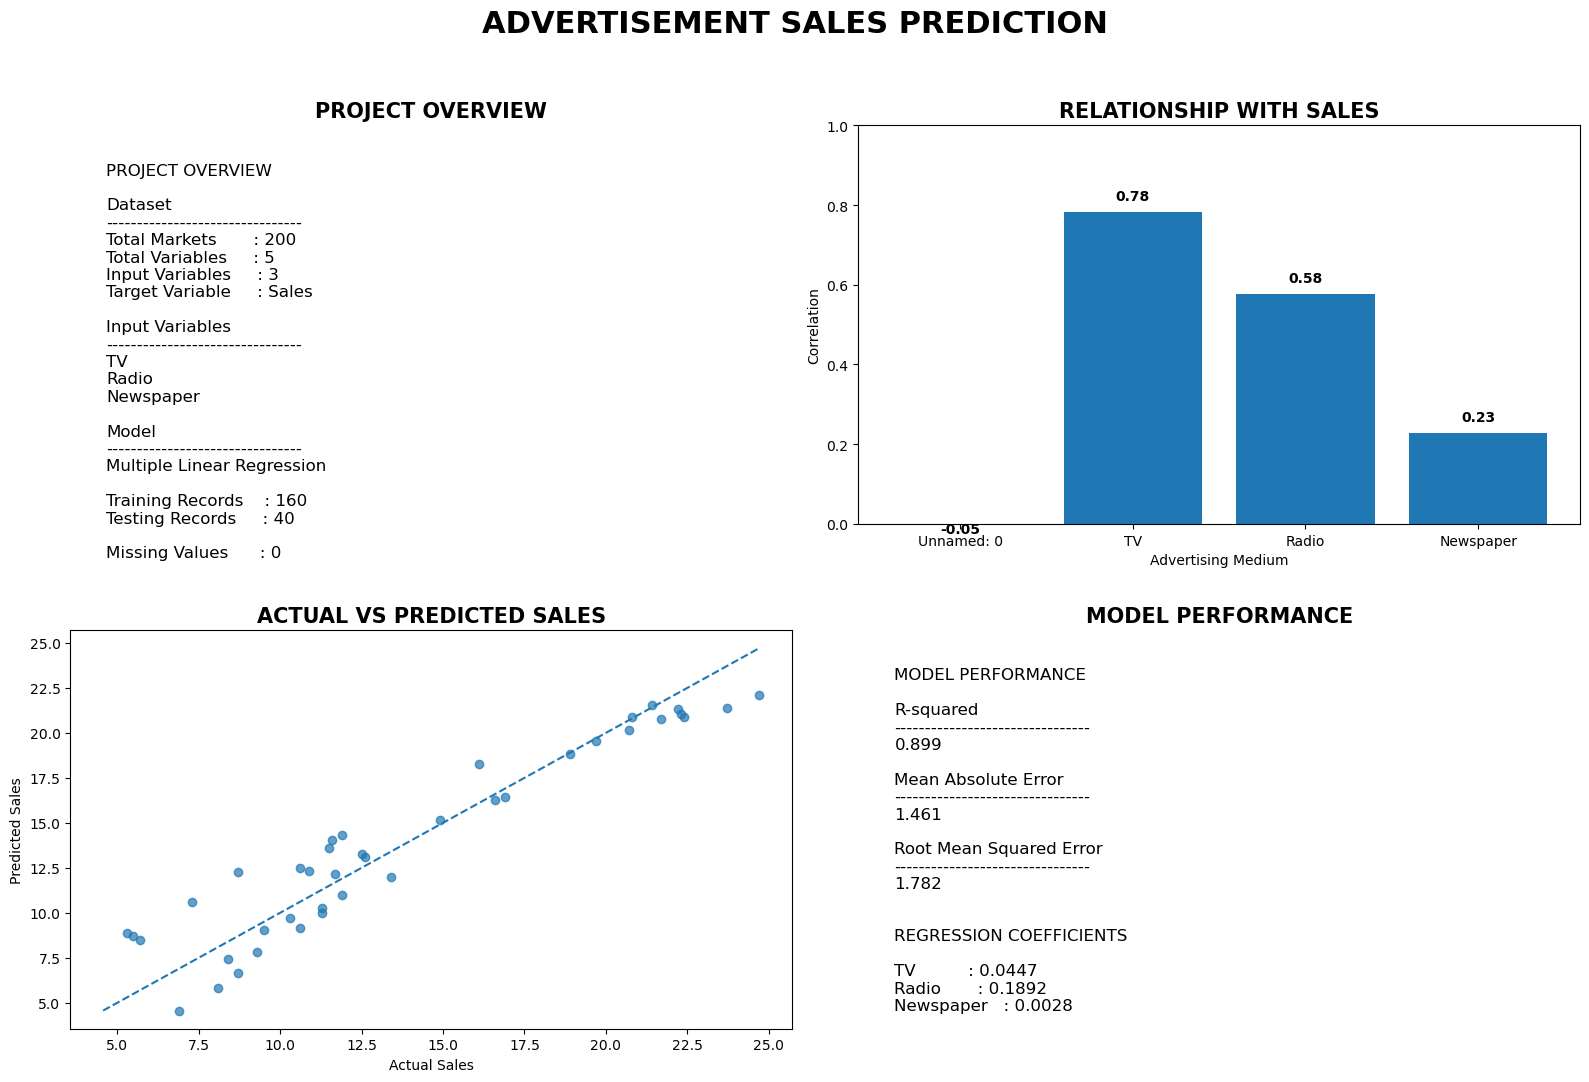



FINAL BUSINESS INSIGHTS

1. The model achieved an R-squared of 0.899 on the test data.

2. TV correlation with Sales: 0.78

3. Radio correlation with Sales: 0.58

4. Newspaper correlation with Sales: 0.23

5. TV and Radio show stronger relationships with Sales than Newspaper.

6. Multiple Linear Regression uses all three advertising variables to predict Sales.

7. The model can be used to estimate Sales from advertising budgets.

PROJECT COMPLETE


In [112]:
# ============================================================
#        ADVERTISEMENT SALES PREDICTION DASHBOARD
# ============================================================

# ------------------------------------------------------------
# 1. PREPARE DATA
# ------------------------------------------------------------

# Use the dataset already loaded as "advertising"

X = advertising[["TV", "Radio", "Newspaper"]]
y = advertising["Sales"]


# ------------------------------------------------------------
# 2. TRAIN MULTIPLE LINEAR REGRESSION MODEL
# ------------------------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


# ------------------------------------------------------------
# 3. MODEL PERFORMANCE
# ------------------------------------------------------------

r2 = r2_score(y_test, y_pred)

mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)


# ------------------------------------------------------------
# 4. CORRELATION
# ------------------------------------------------------------

correlation = advertising.corr(numeric_only=True)

sales_correlation = correlation["Sales"].drop("Sales")


# ------------------------------------------------------------
# 5. CREATE DASHBOARD
# ------------------------------------------------------------

fig = plt.figure(
    figsize=(16, 11)
)

fig.suptitle(
    "ADVERTISEMENT SALES PREDICTION",
    fontsize=22,
    fontweight="bold"
)


# ============================================================
# SECTION 1 - PROJECT OVERVIEW
# ============================================================

ax1 = plt.subplot(2, 2, 1)

ax1.axis("off")

overview = f"""
PROJECT OVERVIEW

Dataset
--------------------------------
Total Markets       : {len(advertising)}
Total Variables     : {advertising.shape[1]}
Input Variables     : 3
Target Variable     : Sales

Input Variables
--------------------------------
TV
Radio
Newspaper

Model
--------------------------------
Multiple Linear Regression

Training Records    : {len(X_train)}
Testing Records     : {len(X_test)}

Missing Values      : {advertising.isnull().sum().sum()}
"""

ax1.text(
    0.05,
    0.95,
    overview,
    fontsize=12,
    verticalalignment="top"
)

ax1.set_title(
    "PROJECT OVERVIEW",
    fontsize=15,
    fontweight="bold"
)


# ============================================================
# SECTION 2 - RELATIONSHIP WITH SALES
# ============================================================

ax2 = plt.subplot(2, 2, 2)

bars = ax2.bar(
    sales_correlation.index,
    sales_correlation.values
)

ax2.set_title(
    "RELATIONSHIP WITH SALES",
    fontsize=15,
    fontweight="bold"
)

ax2.set_xlabel(
    "Advertising Medium"
)

ax2.set_ylabel(
    "Correlation"
)

ax2.set_ylim(
    0,
    1
)

for bar, value in zip(
    bars,
    sales_correlation.values
):

    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.03,
        f"{value:.2f}",
        ha="center",
        fontweight="bold"
    )


# ============================================================
# SECTION 3 - ACTUAL VS PREDICTED
# ============================================================

ax3 = plt.subplot(2, 2, 3)

ax3.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

minimum = min(
    y_test.min(),
    y_pred.min()
)

maximum = max(
    y_test.max(),
    y_pred.max()
)

ax3.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

ax3.set_title(
    "ACTUAL VS PREDICTED SALES",
    fontsize=15,
    fontweight="bold"
)

ax3.set_xlabel(
    "Actual Sales"
)

ax3.set_ylabel(
    "Predicted Sales"
)


# ============================================================
# SECTION 4 - MODEL PERFORMANCE
# ============================================================

ax4 = plt.subplot(2, 2, 4)

ax4.axis("off")

performance = f"""
MODEL PERFORMANCE

R-squared
--------------------------------
{r2:.3f}

Mean Absolute Error
--------------------------------
{mae:.3f}

Root Mean Squared Error
--------------------------------
{rmse:.3f}


REGRESSION COEFFICIENTS

TV          : {model.coef_[0]:.4f}
Radio       : {model.coef_[1]:.4f}
Newspaper   : {model.coef_[2]:.4f}
"""

ax4.text(
    0.05,
    0.95,
    performance,
    fontsize=12,
    verticalalignment="top"
)

ax4.set_title(
    "MODEL PERFORMANCE",
    fontsize=15,
    fontweight="bold"
)


# ============================================================
# FINAL DASHBOARD DISPLAY
# ============================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()


# ============================================================
# FINAL BUSINESS INSIGHTS
# ============================================================

print("\n")
print("=" * 65)
print("FINAL BUSINESS INSIGHTS")
print("=" * 65)

print(
    f"\n1. The model achieved an R-squared of {r2:.3f} "
    "on the test data."
)

print(
    f"\n2. TV correlation with Sales: "
    f"{sales_correlation['TV']:.2f}"
)

print(
    f"\n3. Radio correlation with Sales: "
    f"{sales_correlation['Radio']:.2f}"
)

print(
    f"\n4. Newspaper correlation with Sales: "
    f"{sales_correlation['Newspaper']:.2f}"
)

print(
    "\n5. TV and Radio show stronger relationships "
    "with Sales than Newspaper."
)

print(
    "\n6. Multiple Linear Regression uses all three "
    "advertising variables to predict Sales."
)

print(
    "\n7. The model can be used to estimate Sales "
    "from advertising budgets."
)

print("\n" + "=" * 65)
print("PROJECT COMPLETE")
print("=" * 65)